In [40]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
import numpy as np
from sklearn.neighbors import KernelDensity

def cluster_by_kde_contours(X_decomp, kde, n_groups, min_cluster_len=100):

    X, Y = np.meshgrid(
        np.linspace(-1.01, 1.01, 100), 
        np.linspace(-1.01, 1.01, 100)
    )
    Z = np.vstack([Y.ravel(), X.ravel()]).T
    # density at gridpoints
    Z = np.exp(kde.score_samples(Z)).reshape(X.shape)

    levels = np.linspace(Z.min(), Z.max(), n_groups+2)

    fig, ax = plt.subplots()
    contours = ax.contourf(X, Y, Z, levels=levels)
    plt.close(fig)

    # contour polygon containment clustering
    cluster_labels = np.full(X_decomp.shape[0], fill_value=-1)
    for cluster_id, path in enumerate(contours.get_paths()):
            poly = Path(path.vertices)
            inside = poly.contains_points(X_decomp)
            cluster_labels[inside] = cluster_id
            
    # if cluster size is smaller than minimum, combine it with the next cluster along
    smallest_cluster_len = -np.inf
    while smallest_cluster_len < min_cluster_len:
        cluster_lens = []
        for i in np.unique(cluster_labels):
            c_idxs = np.where(cluster_labels==i)[0]
            c_len = len(c_idxs)
            cluster_lens.append(c_len)
            if c_len < min_cluster_len:
                for j in c_idxs:
                    cluster_labels[j] = i+1

        smallest_cluster_len = min(cluster_lens)
                    
    # Alternative fast binning by quantiles (doesn't match contours exactly, but is cheap)
    #thresholds = np.quantile(density, np.linspace(0, 1, n_groups + 1))
    #cluster_labels = np.digitize(density, thresholds[1:], right=True)
    
    return Z, contours, cluster_labels, cluster_lens

def plot_decomp_kde_2D_clustered(X, Z, ax, cluster_labels, cluster_lens, include_lens=True):
    """ Plot decomposition with KDE contours
        color X by cluster label
        plot a mini bar graph on top of the axes for cluster lens
    """
    xx, yy = np.meshgrid(
        np.linspace(-1.01, 1.01, 100), 
        np.linspace(-1.01, 1.01, 100)
    )

    levels = np.linspace(Z.min(), Z.max(), 12)
    ax.contourf(xx, yy, Z, levels=levels, cmap=plt.cm.Reds)
    ax.scatter(X[:,0], X[:,1], s=5, c=cluster_labels, cmap="viridis")
    ax.grid(True)

    if include_lens:
        inset_ax = ax.inset_axes([0.1, 1.05, 0.8, 0.2])
        inset_ax.bar(np.unique(cluster_labels), cluster_lens, color="blue", alpha=0.7)    
        inset_ax.set_ylabel("Cluster Size")

    return

def plot_decomp_kde_2D_affinity_heatmap(X, Z, scores, ax):
    """ Plot decomposition with KDE contours
        color X by cluster label
        plot a mini bar graph on top of the axes for cluster lens
    """
    xx, yy = np.meshgrid(
        np.linspace(-1.01, 1.01, 100), 
        np.linspace(-1.01, 1.01, 100)
    )

    levels = np.linspace(Z.min(), Z.max(), 12)
    ax.contourf(xx, yy, Z, levels=levels, cmap=plt.cm.Reds)
    ax.scatter(X[:,0], X[:,1], s=5, c=scores, cmap="viridis")
    ax.grid(True)

    return

def plot_bar_cluster_lens(cluster_labels, cluster_lens, ax):
    """ Plot decomposition with KDE contours
        color X by cluster label
        plot a mini bar graph on top of the axes for cluster lens
    """
    ax.bar(np.unique(cluster_labels), cluster_lens, color="blue", alpha=0.7)    
    ax.set_ylabel("Cluster Size")
    ax.set_xlabel("Cluster Number")

    return

In [4]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.pipeline import Pipeline
from sklearn.decomposition import KernelPCA
from sklearn.manifold import Isomap
from sklearn.preprocessing import MinMaxScaler


smi_file = "/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/fp_decomp_kde/fp_decomp_testing_pipeline/data/hydros8992.smi"

smis = [i.strip() for i in open(smi_file).readlines()]
fpgen = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)
#fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = np.array([fpgen.GetFingerprint(Chem.MolFromSmiles(s)) for s in smis])

pipe = Pipeline([("decomp", Isomap(n_components=2)), ("scaler", MinMaxScaler((-1, 1)))])
#pipe = Pipeline([("decomp", KernelPCA(n_components=2, kernel="rbf")), ("scaler", MinMaxScaler((-1, 1)))])

X = pipe.fit_transform(fps)

/home/andyt/miniconda3/envs/regression_sandbox/lib/python3.9/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 3 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/andyt/miniconda3/envs/regression_sandbox/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/andyt/miniconda3/envs/regression_sandbox/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/andyt/miniconda3/envs/regression_sandbox/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure 

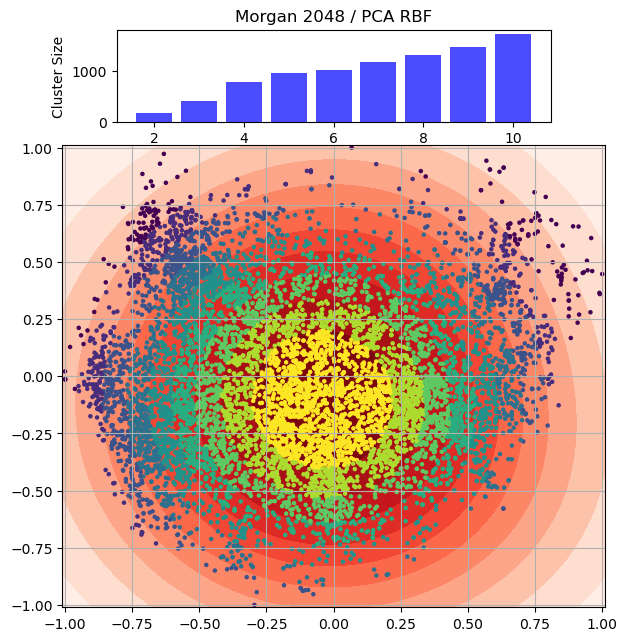

In [5]:
kde = KernelDensity(kernel="gaussian", bandwidth=0.5)
kde.fit(X)
Z, contours, cluster_labels, cluster_lens = cluster_by_kde_contours(X, kde, 10, min_cluster_len=100)

fig, ax = plt.subplots(figsize=(7,6))
plot_decomp_kde_2D_clustered(X, Z, ax, cluster_labels, cluster_lens)
ax.set_title("Morgan 2048 / PCA RBF")
plt.show()

In [11]:
""" Plot the training set next to 10k randomly generated molecules from RNNs:
    - no modification
    - SMILES augmentation by KDE cluster sizes
    - Sample weighting by KDE cluster sizes
"""
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

smi_random = "/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/random_mol_gen/hydros8992/valid.smi"
smis_random = [i.strip() for i in open(smi_random).readlines()]
fps_random = np.array([fpgen.GetFingerprint(Chem.MolFromSmiles(s)) for s in smis_random])
X_random = pipe.transform(fps_random)

smi_weights = "/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/random_mol_gen/hydros8992_atom_pair_isomap_weighted/valid.smi"
smis_weights = [i.strip() for i in open(smi_weights).readlines()]
fps_weights = np.array([fpgen.GetFingerprint(Chem.MolFromSmiles(s)) for s in smis_weights])
X_weights = pipe.transform(fps_weights)

smi_augmented = "/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/random_mol_gen/hydros8992_atom_pair_isomap_augmented/valid.smi"
smis_augmented = [i.strip() for i in open(smi_augmented).readlines()]
fps_augmented = np.array([fpgen.GetFingerprint(Chem.MolFromSmiles(s)) for s in smis_augmented])
X_augmented = pipe.transform(fps_augmented)

to_plot = {"Training Set":X,
           "Random Generated":X_random, 
           "Random Generated with Weighting":X_weights, 
           "Random generated with Augmentation":X_augmented,
          }

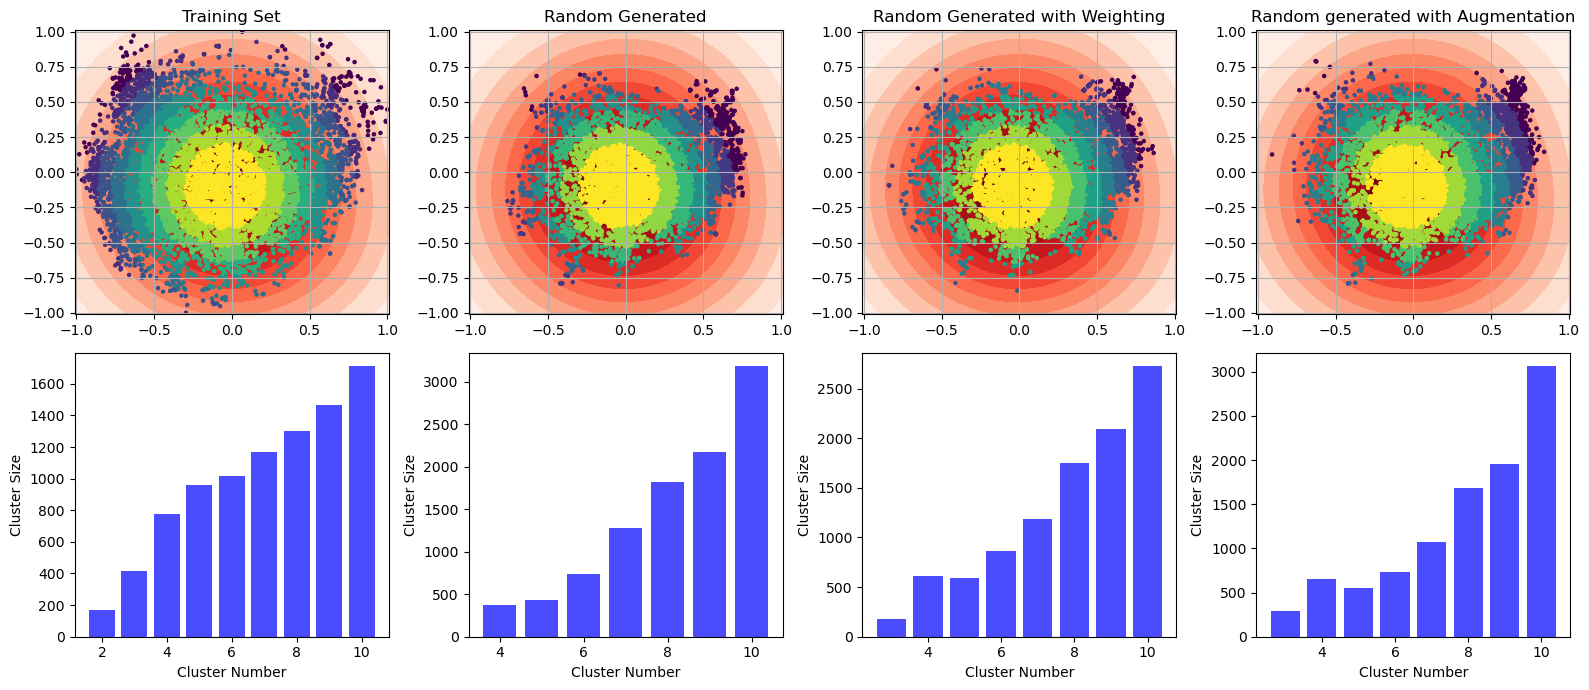

In [21]:
fig, ax = plt.subplots(2, 4, figsize=(16, 7))
ax = ax.flatten()

for i, (key, val) in enumerate(to_plot.items()):
    Z, contours, cluster_labels, cluster_lens = cluster_by_kde_contours(val, kde, 10, min_cluster_len=100)
    plot_decomp_kde_2D_clustered(val, Z, ax[i], cluster_labels, cluster_lens, include_lens=False)
    ax[i].set_title(key)
    plot_bar_cluster_lens(cluster_labels, cluster_lens, ax[i+4])
plt.tight_layout()
plt.show()

In [34]:
import pandas as pd
mcts = pd.read_csv("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/result/24_07_25/result_C0.7.csv")
mcts = mcts.dropna(subset=["VinaScore"])

smis_mcts = mcts["smiles"].to_list()
fps_mcts = np.array([fpgen.GetFingerprint(Chem.MolFromSmiles(s)) for s in smis_mcts])
X_mcts = pipe.transform(fps_mcts)

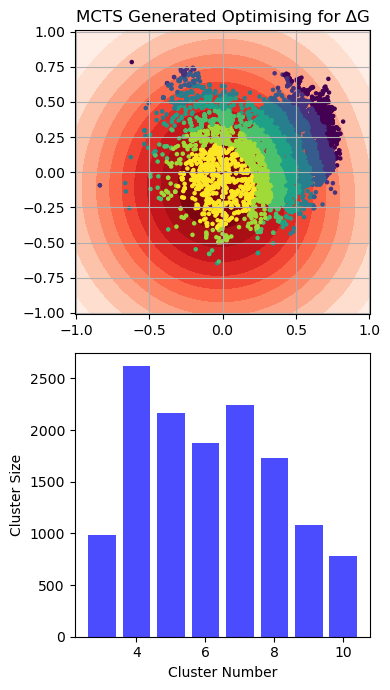

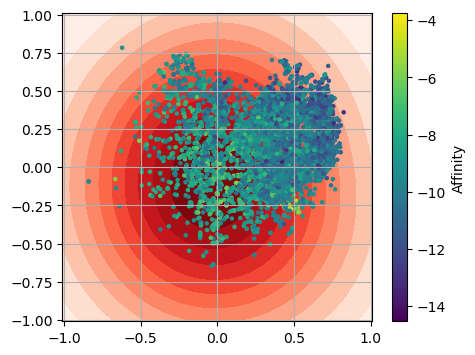

In [48]:
fig, ax = plt.subplots(2, 1, figsize=(4, 7))
ax = ax.flatten()

Z, contours, cluster_labels, cluster_lens = cluster_by_kde_contours(X_mcts, kde, 10, min_cluster_len=100)
plot_decomp_kde_2D_clustered(X_mcts, Z, ax[0], cluster_labels, cluster_lens, include_lens=False)
ax[0].set_title("MCTS Generated Optimising for \u0394G")
plot_bar_cluster_lens(cluster_labels, cluster_lens, ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
plot_decomp_kde_2D_affinity_heatmap(X_mcts, Z, mcts["VinaScore"].to_list(), ax)
norm = plt.Normalize(mcts['VinaScore'].min(), mcts['VinaScore'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
plt.colorbar(sm, label='Affinity', ax=ax)

plt.show()

In [58]:
def get_max_density_point(X_decomp, kde):
    """ Get the point of max density and density value from a set of X decomposed points and a trained kde object
    """
    kde_at_decomp = np.exp(kde.score_samples(X_decomp))
    max_idx = np.argmax(kde_at_decomp)

    max_point = X_decomp[max_idx]
    max_density = kde_at_decomp.max()

    return max_point, max_density

get_max_density_point(X, kde)

(array([-0.10134852, -0.05087803]), 0.3841073579936687)